# Construction Project Expense & Classification Model Training

This notebook trains a Task Group classifier using:
`dataset/Construction_Data_PM_Tasks_All_Projects.csv`

In [ ]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support

In [ ]:
# Data loading
DATASET_PATH = os.path.join('..', 'dataset', 'Construction_Data_PM_Tasks_All_Projects.csv')
df = pd.read_csv(DATASET_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (12424, 19)
Columns: ['Ref', 'Status', 'Location', 'Description', 'Created', 'Target', 'Type', 'To Package', 'Status Changed', 'Association', 'OverDue', 'Images', 'Comments', 'Documents', 'Priority', 'Cause', 'project', 'Report Status', 'Task Group']


,Ref,Status,Location,Description,Created,Target,Type,To Package,Status Changed,Association,OverDue,Images,Comments,Documents,Priority,Cause,project,Report Status,Task Group
0,T1.23963030,Open,JPC Project Management>EHS Management>01 Inspe...,task raised in incorrect location of this form...,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,14/09/2020,FormAnswer,False,NaN,NaN,NaN,Behavioural Failure,JPC - Safety - Documentation,1328,Open,Safety
1,T116412.200,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,Metsec,14/09/2020,NaN,JPC - Progress Photo,Ceilings & Partitions,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
2,T141663.27,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,Good clear exclusion zones and access through ...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - Access,1328,Closed,Safety
3,T116412.199,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,RC walls,14/09/2020,NaN,JPC - Progress Photo,Precast Concrete,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
4,T141663.26,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,"block 02 working level has good housekeeping, ...",14/09/2020,NaN,Safety Notice (Green) - Good Observation,Precast Concrete,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - House Keeping,1328,Closed,Safety


In [ ]:
# Data cleaning

def clean_text(text):
    text = str(text or '').lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

required_cols = ['Description', 'Task Group']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f'Missing required column: {col}')

df = df.dropna(subset=['Description', 'Task Group']).copy()
df['Type'] = df['Type'].fillna('') if 'Type' in df.columns else ''
df['Cause'] = df['Cause'].fillna('') if 'Cause' in df.columns else ''
df['text'] = (df['Description'].astype(str) + ' ' + df['Type'].astype(str) + ' ' + df['Cause'].astype(str)).apply(clean_text)
df = df[(df['text'] != '') & (df['Task Group'].astype(str).str.strip() != '')]
print('Clean rows:', len(df))

Clean rows: 12374


In [ ]:
# Feature engineering and split (80/20)
X = df['text']
y = df['Task Group'].astype(str)

vectorizer = TfidfVectorizer(max_features=7000, ngram_range=(1, 2))
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Train samples: 9899
Test samples: 2475


In [ ]:
# Model training with multiple algorithms - pick the best one
print("=" * 60)
print("TRAINING MULTIPLE ALGORITHMS...")
print("=" * 60)

models = {
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42, dual=False),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
best_model_name = None
best_accuracy = 0
best_model = None

for name, model in models.items():
    print(f"\n▶ Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    print(f"   ✓ Accuracy: {accuracy:.4f}")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name
        best_model = model

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name} ({best_accuracy:.4f})")
print(f"{'='*60}")

y_pred = results[best_model_name]['predictions']
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print(f'\nWeighted Metrics:')
print(f'  Precision: {precision:.4f}')
print(f'  Recall: {recall:.4f}')
print(f'  F1-Score: {f1:.4f}')

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9891

Classification Report:
                 precision    recall  f1-score   support

    Design Team       1.00      0.98      0.99       228
        Quality       0.99      0.88      0.93       186
         Safety       0.99      1.00      0.99      1777
Site Management       0.99      1.00      1.00       284

       accuracy                           0.99      2475
      macro avg       0.99      0.96      0.98      2475
   weighted avg       0.99      0.99      0.99      2475



In [ ]:
# Hyperparameter tuning for best model
if best_model_name == 'Linear SVM':
    print("\n" + "="*60)
    print("HYPERPARAMETER TUNING FOR LINEAR SVM...")
    print("="*60)
    
    param_grid = {
        'C': [0.1, 1, 10, 100],
    }
    
    svm = LinearSVC(max_iter=2000, random_state=42, dual=False)
    grid_search = GridSearchCV(svm, param_grid, cv=3, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    
    print(f"\nBest C: {grid_search.best_params_['C']}")
    print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")
    
    best_model = grid_search.best_estimator_
    y_pred_tuned = best_model.predict(X_test)
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    print(f"Test Accuracy after tuning: {accuracy_tuned:.4f}")
    best_accuracy = accuracy_tuned
    y_pred = y_pred_tuned


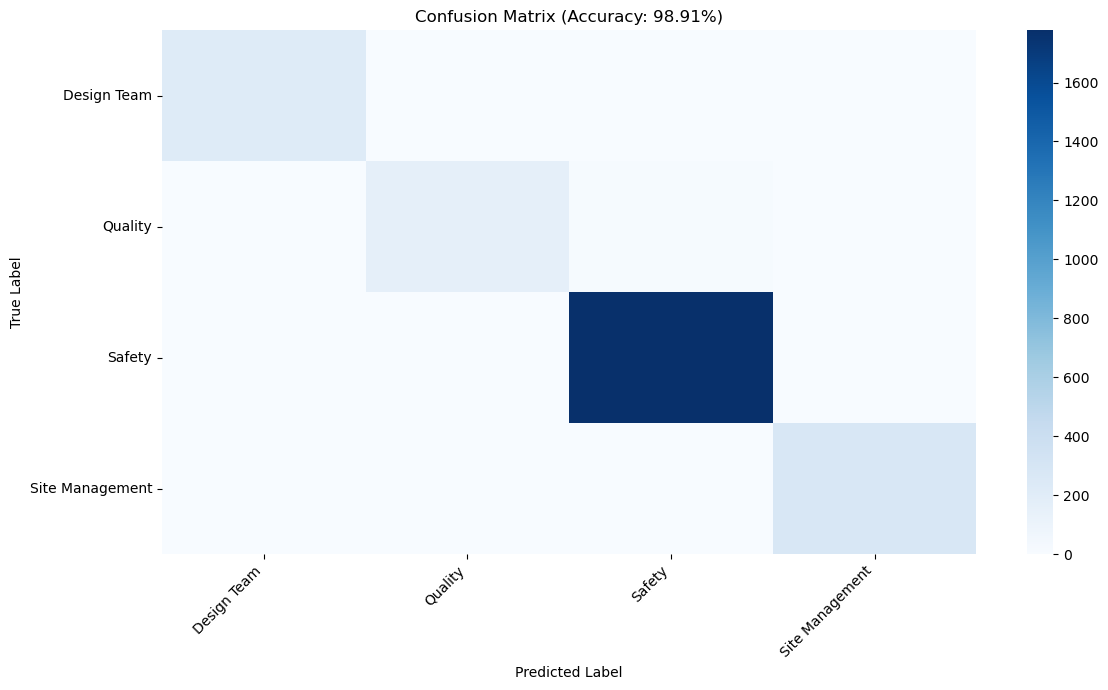

In [ ]:
# Confusion matrix visualization
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(12, 7))
sns.heatmap(cm, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2%})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Save best model artifacts
joblib.dump(best_model, 'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump(best_model_name, 'model_name.pkl')

print(f'✅ Saved: model.pkl, vectorizer.pkl, model_name.pkl')
print(f'   Model Type: {best_model_name}')
print(f'   Accuracy: {best_accuracy:.4f}')

Saved: model.pkl, vectorizer.pkl
